Прогнозирование ARIMA

M3_Competition

https://github.com/jordicolomer/m3-competition/blob/master/generate_table.py


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline


In [2]:
#    conda install xlrd

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf


statsmodels.tsa.arima_model.ARMA and <br>
statsmodels.tsa.arima_model.ARIMA <br> 
have been removed in favor of  <br>
statsmodels.tsa.arima.model.ARIMA (note the . between arima and model) and  <br>
statsmodels.tsa.SARIMAX.

In [5]:
test = {}
train = {}
M3C = pd.ExcelFile('M3C.xls')
for sheet in 'M3Year M3Quart M3Month M3Other'.split():
    M3Year = M3C.parse(sheet).to_numpy()
    for row in M3Year:
        series = row[0]
        N = row[1]
        NF = row[2]
        train[series] = row[6:6+N-NF]
        test[series] = row[6+N-NF:6+N]


In [6]:
test

{'N   1': array([5379.75, 6158.68, 6876.58, 7851.91, 8407.84, 9156.01], dtype=object),
 'N   2': array([4793.2, 5602.0, 5065.0, 5056.0, 5067.2, 5209.6], dtype=object),
 'N   3': array([3070.2, 3601.6, 3407.4, 3500.6, 3437.8, 3007.0], dtype=object),
 'N   4': array([4656.0, 5228.52, 5656.72, 5077.02, 5403.4, 5009.52], dtype=object),
 'N   5': array([5250.9, 4899.2, 4317.9, 4007.9, 4323.4, 4819.4], dtype=object),
 'N   6': array([4338.03, 4185.92, 3950.49, 3715.59, 3958.3, 4140.39], dtype=object),
 'N   7': array([5163.21, 5089.94, 4786.4, 4926.47, 5068.83, 5318.19], dtype=object),
 'N   8': array([8809.8, 8953.5, 7991.01, 7294.08, 7163.37, 7478.31], dtype=object),
 'N   9': array([6277.6, 7446.28, 6741.69, 6600.69, 7850.17, 8485.26], dtype=object),
 'N  10': array([10042.9, 10173.0, 8751.0, 3472.0, 3187.0, 3058.0], dtype=object),
 'N  11': array([5388.4, 5766.2, 5937.9, 5627.4, 5982.7, 5931.6], dtype=object),
 'N  12': array([5949.5, 6616.5, 7247.0, 8205.0, 10158.5, 12495.5], dtype=obje

In [7]:
type(train)

dict

N 152

In [9]:
zzz1 = pd.DataFrame(train['N 152'])

In [10]:
zzz1

,0
0,5717.0
1,6374.0
2,5837.5
3,7318.4
4,4613.0
5,4611.4
6,5623.6
7,6058.7
8,6449.9
9,5711.2


In [11]:
zzz1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       38 non-null     object
dtypes: object(1)
memory usage: 436.0+ bytes


In [12]:
zzz1[0] = pd.to_numeric(zzz1[0])

In [13]:
zzz1.columns

RangeIndex(start=0, stop=1, step=1)

In [14]:
zzz1.to_csv('M3_152.csv', columns=None, header=True)

<Axes: >

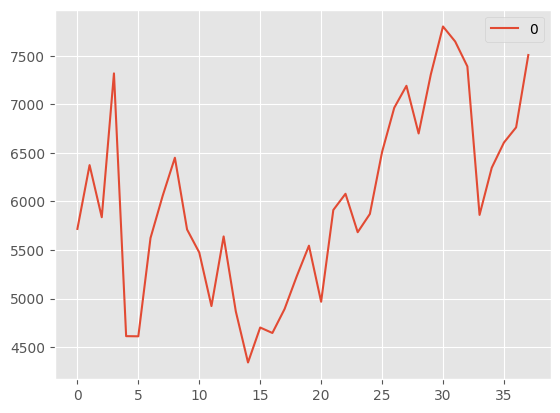

In [15]:
zzz1.plot()

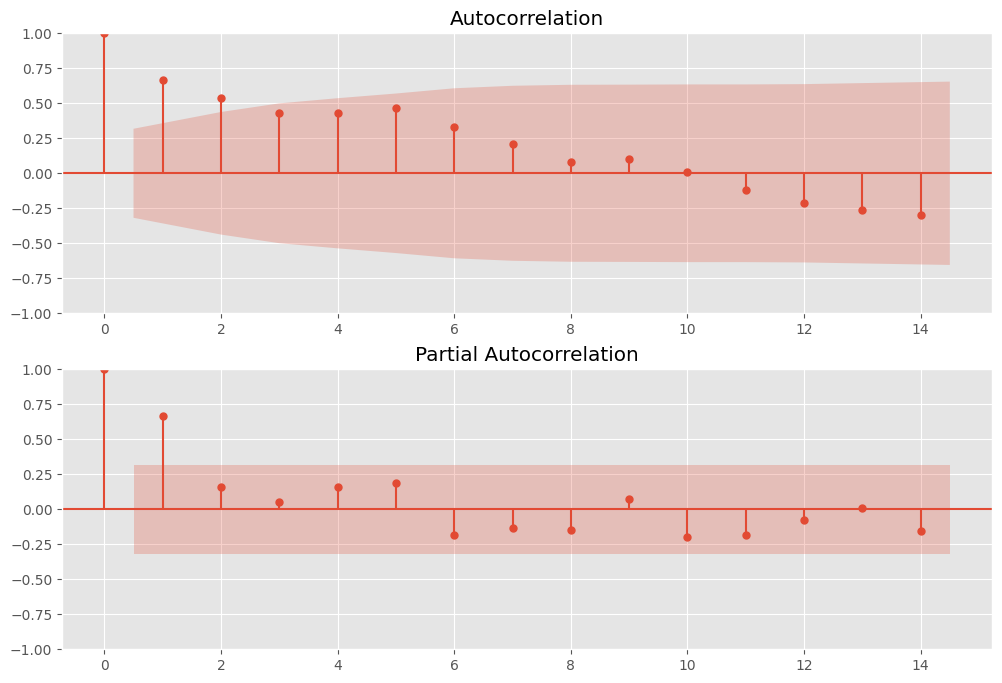

In [16]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(zzz1, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(zzz1, method='ywmle', lags=14, ax=plt.gca())
plt.show()

In [17]:
# строим модель
model = ARIMA(zzz1, order=(1,0,0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   38
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -302.554
Date:                Fri, 15 May 2026   AIC                            611.107
Time:                        17:37:45   BIC                            616.020
Sample:                             0   HQIC                           612.855
                                 - 38                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6059.1023    417.649     14.508      0.000    5240.526    6877.679
ar.L1          0.6988      0.149      4.692      0.000       0.407       0.991
sigma2      4.737e+05   1.09e+05      4.352      0.0

In [18]:
# анализ остатков
residuals = pd.DataFrame(model_fit.resid)


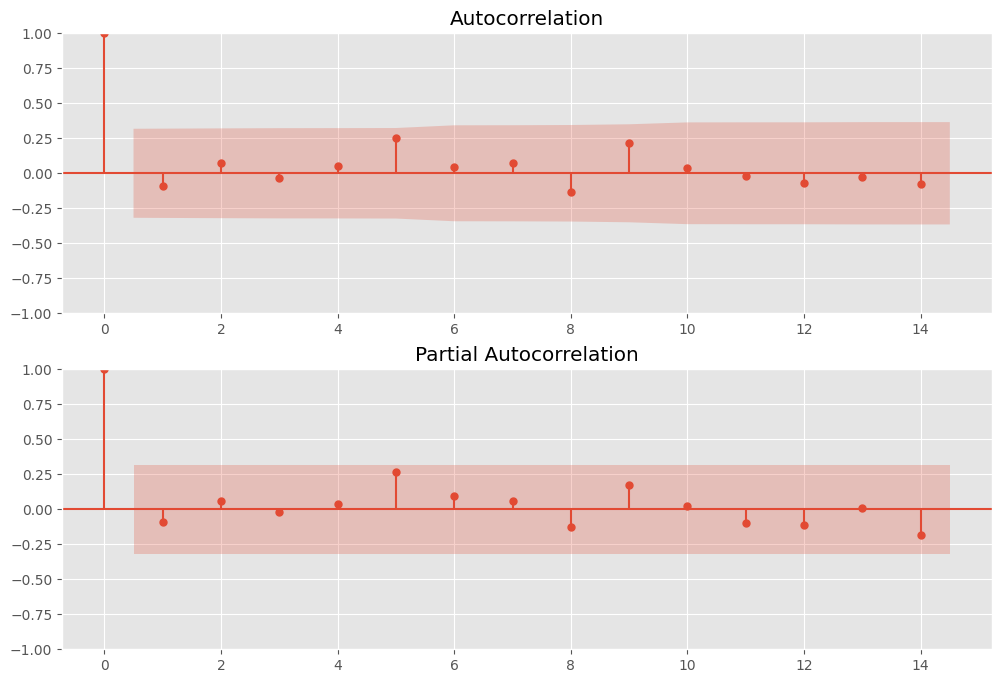

In [19]:
plt.figure(figsize=(12,8))

plt.subplot(211)
plot_acf(residuals, lags=14, ax=plt.gca())

plt.subplot(212)
plot_pacf(residuals, method='ywmle', lags=14, ax=plt.gca())
plt.show()


In [20]:
zzz1 = pd.DataFrame(train['N 153'])

zzz1

,0
0,1550.61
1,1488.54
2,1200.03
3,1451.49
4,2576.19
5,2434.2
6,2586.21
7,1898.55
8,2958.18
9,3290.73


In [21]:
zzz1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       38 non-null     object
dtypes: object(1)
memory usage: 436.0+ bytes


In [22]:
zzz1[0] = pd.to_numeric(zzz1[0])

zzz1.columns



RangeIndex(start=0, stop=1, step=1)

In [23]:
zzz1.to_csv('M3_153.csv', columns=None, header=True)

In [24]:
#   zzz1.plot()

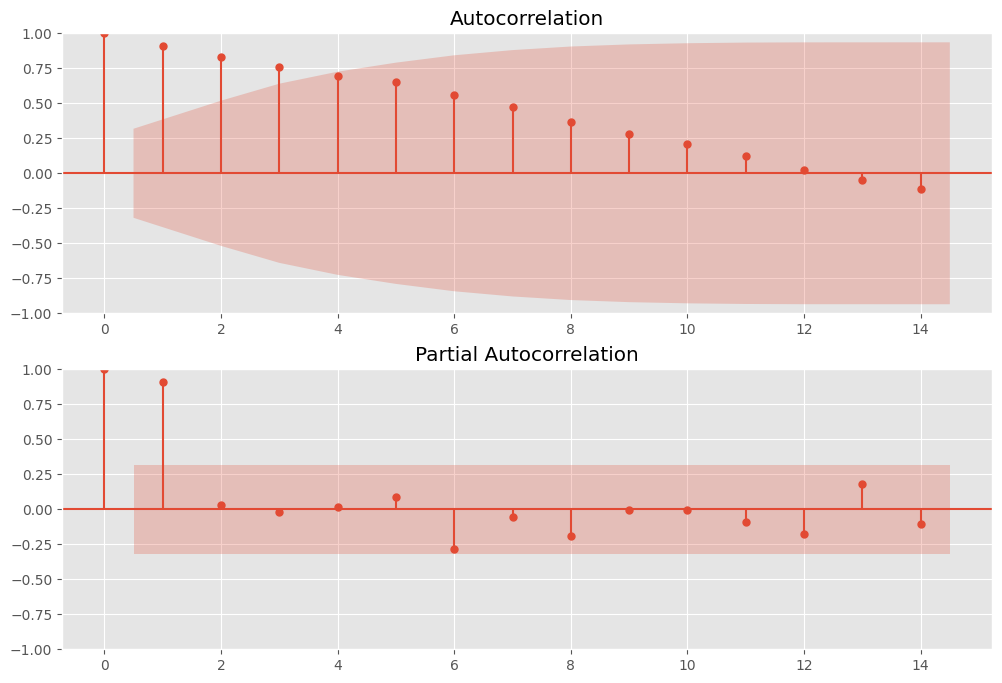

In [25]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(zzz1, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(zzz1, method='ywmle', lags=14, ax=plt.gca())
plt.show()

In [26]:
# строим модель
model = ARIMA(zzz1, order=(1,0,0))
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   38
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -298.822
Date:                Fri, 15 May 2026   AIC                            603.644
Time:                        17:37:57   BIC                            608.556
Sample:                             0   HQIC                           605.392
                                 - 38                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       4942.9683   1830.374      2.701      0.007    1355.502    8530.435
ar.L1          0.9641      0.053     18.193      0.000       0.860       1.068
sigma2        3.7e+05   1.09e+05      3.394      0.0

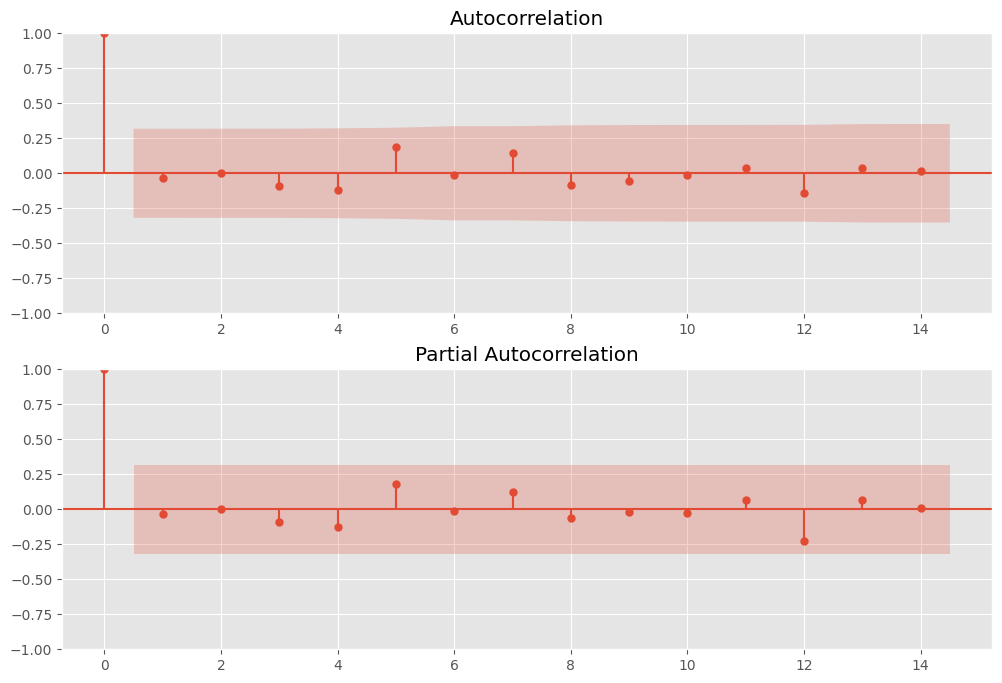

In [27]:
# анализ остатков
residuals = pd.DataFrame(model_fit.resid)

plt.figure(figsize=(12,8))

plt.subplot(211)
plot_acf(residuals, lags=14, ax=plt.gca())

plt.subplot(212)
plot_pacf(residuals, method='ywmle', lags=14, ax=plt.gca())
plt.show()


In [28]:
#  Перейдем к разностям
zzz_2 = zzz1.diff(periods=1)

In [29]:
zzz_3 = zzz_2.dropna()

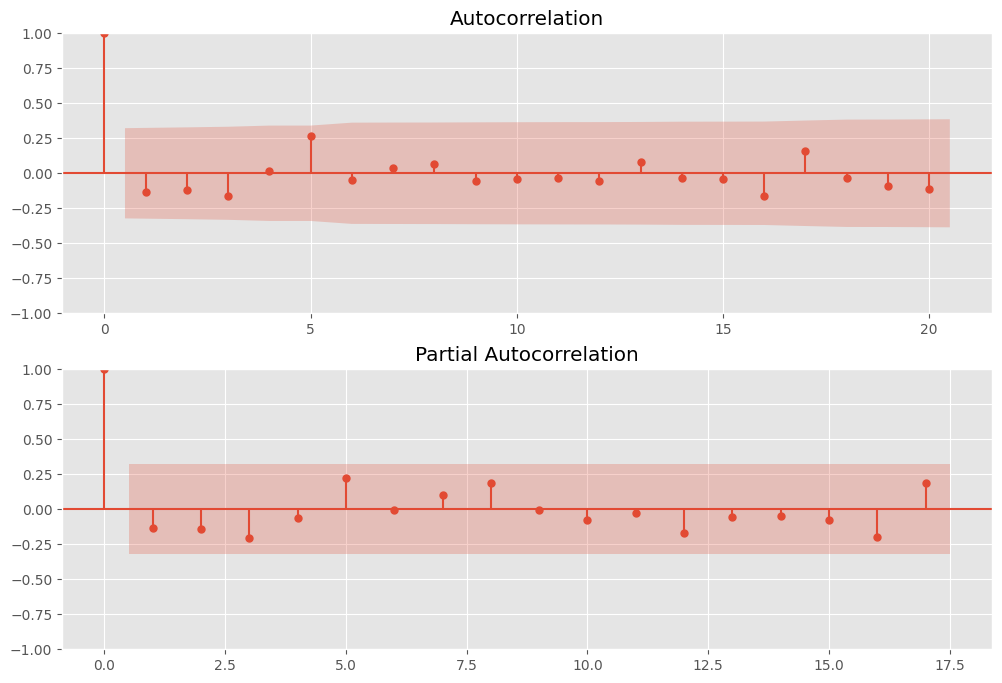

In [30]:
plt.figure(figsize=(12,8))
plt.subplot(211)

plot_acf(zzz_3, lags=20, ax=plt.gca())
plt.subplot(212)

plot_pacf(zzz_3, method='ywmle', lags=17, ax=plt.gca())
plt.show()

Вывод для 153 ряда  <br> 
ARIMA(1,0,0) <br> 
ARIMA(0,1,0) <br> 

KISS =>  ARIMA(0,1,0) 


N 154

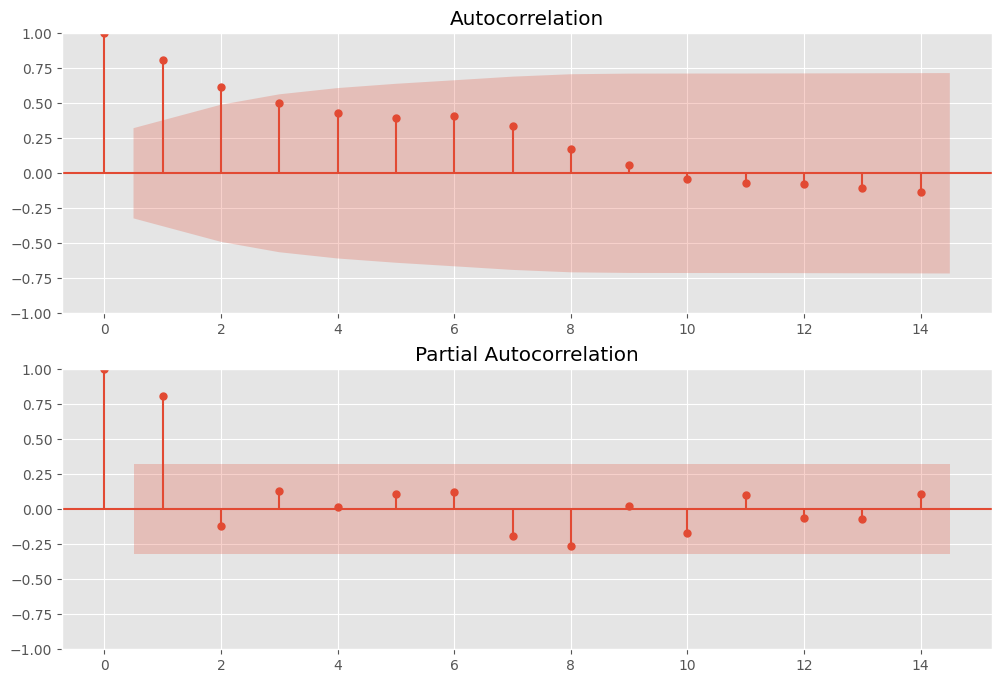

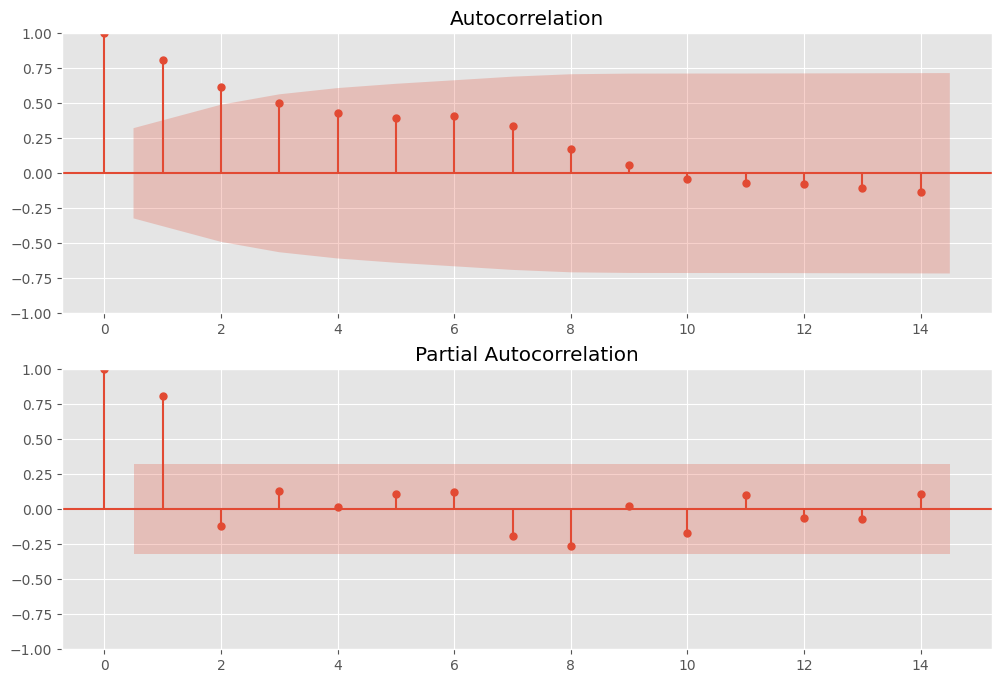

In [31]:
zzz1 = pd.DataFrame(train['N 154'])

zzz1[0] = pd.to_numeric(zzz1[0])

zzz1.to_csv('M3_154.csv', columns=None, header=True)


plt.figure(figsize=(12,8))

plt.subplot(211)
plot_acf(zzz1, lags=14, ax=plt.gca())

plt.subplot(212)
plot_pacf(zzz1, method='ywmle', lags=14, ax=plt.gca())



In [32]:
# строим модель
model = ARIMA(zzz1, order=(1,0,0))
model_fit = model.fit()
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   37
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -297.671
Date:                Fri, 15 May 2026   AIC                            601.342
Time:                        17:38:01   BIC                            606.175
Sample:                             0   HQIC                           603.046
                                 - 37                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1563.7757   1377.109      1.136      0.256   -1135.307    4262.859
ar.L1          0.8004      0.107      7.447      0.000       0.590       1.011
sigma2      5.538e+05   1.21e+05      4.571      0.0

Вывод для 154 ряда  <br> 
ARIMA(1,0,0) <br> 

